see if models trained learn mapping f(embedding) = precipitation for a single RainShift region can transfer zero-shot to another 

In [ ]:
import xarray as xr

train_region = "europe_west"
train_area_path = f"data/rainshift_dataset/{train_region}/"
train_out_ds = xr.open_zarr(train_area_path + "test_data_out.zarr")
train_in_ds = xr.open_zarr(train_area_path + "test_data_in.zarr")

test_regions = ["blacksea", "northamerica-west", "west-africa"]
test_out_ds_by_region = {}
test_in_ds_by_region = {}
for test_region in test_regions:
    test_area_path = f"data/rainshift_dataset/{test_region}/"
    test_out_ds_by_region[test_region] = xr.open_zarr(test_area_path + "test_data_out.zarr")
    test_in_ds_by_region[test_region] = xr.open_zarr(test_area_path + "test_data_in.zarr")

In [2]:
train_out_ds

<xarray.Dataset> Size: 3GB
Dimensions:        (time: 17520, latitude: 200, longitude: 200)
Coordinates:
  * latitude       (latitude) float32 800B 59.95 59.85 59.75 ... 40.15 40.05
  * longitude      (longitude) float32 800B 355.0 355.1 355.2 ... 14.85 14.95
Dimensions without coordinates: time
Data variables:
    precipitation  (time, latitude, longitude) float32 3GB ...

In [2]:
# load satclip model

# Ensure Hugging Face and Torch caches are set before imports
import os
import sys
import pyproj
from huggingface_hub import hf_hub_download
import torch

cwd = os.getcwd()

cache_dir = "/home/sazhang/.cache"
hf_cache = f"{cache_dir}/huggingface"
torch_cache = f"{cache_dir}/torch"

os.environ["HF_HOME"] = hf_cache
os.environ["HF_HUB_CACHE"] = f"{hf_cache}/hub"
os.environ["TRANSFORMERS_CACHE"] = f"{hf_cache}/transformers"
os.environ["TORCH_HOME"] = torch_cache

import importlib
import huggingface_hub.constants as hf_const
importlib.reload(hf_const)
print("HF_HOME:", hf_const.HF_HOME)
print("HF_HUB_CACHE:", hf_const.HF_HUB_CACHE)
print("TORCH_HOME:", os.environ["TORCH_HOME"])


sys.path.append(f'{cwd}/satclip/satclip') # add satclip module from satclip repo to path

# Explicitly set via pyproj API
conda_env_path = "/home/sazhang/miniconda3/envs/downscaling"
proj_path = f"{conda_env_path}/share/proj"

os.environ["PROJ_LIB"] = proj_path
os.environ["PROJ_DATA"] = proj_path

pyproj.datadir.set_data_dir(proj_path)


device = "cuda" if torch.cuda.is_available() else "cpu"

from load import get_satclip
model = get_satclip(
    hf_hub_download("microsoft/SatCLIP-ResNet18-L40", "satclip-resnet18-l40.ckpt", cache_dir=cache_dir),
    device=device,
)  # Only loads location encoder by default


/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HF_HOME: /home/sazhang/.cache/huggingface
HF_HUB_CACHE: /home/sazhang/.cache/huggingface/hub
TORCH_HOME: /home/sazhang/.cache/torch


/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


using pretrained moco resnet18


In [3]:
# load aef embeddings

import xarray as xr
import s3fs
import numpy as np

aef_ds = xr.open_zarr("s3://us-west-2.opendata.source.coop/tge-labs/aef-mosaic/", consolidated=False, storage_options={"anon": True}) 

def dequantize_embedding(y, power=2.0, scale=127.5):
    """Restores the int8 embedding back to its original float32 representation."""
    rescaled = y.astype(np.float32) / scale
    return (np.abs(rescaled) ** power) * np.sign(rescaled)



/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/zarr/core/group.py:3559: ZarrUserWarning: Object at .checkpoint is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/zarr/core/group.py:3559: ZarrUserWarning: Object at README.md is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [13]:
import numpy as np

def get_coords(out_ds):
    # Coordinates
    lat = out_ds['latitude'].values
    lon = out_ds['longitude'].values

    # Create a meshgrid
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    # Flatten
    lon_flat = lon_grid.flatten()
    lat_flat = lat_grid.flatten()

    # SatCLIP takes coordinates as (lon, lat)
    coords = np.stack([lon_flat, lat_flat], axis=1)
    return coords  # (N, 2)

def get_sinusoidal_embeddings(out_ds):
    coords = get_coords(out_ds)
    coords_rad = np.radians(coords)  # Convert for trig functions

    # Generate Sinusoidal Embeddings (Fourier Features)
    # We use multiple frequencies to capture both broad regional patterns and local details
    frequencies = [1, 2, 4, 8, 16]
    embedded_coords = []

    for freq in frequencies:
        # Apply sin and cos to both lat and lon at the current frequency
        embedded_coords.append(np.sin(coords_rad * freq))
        embedded_coords.append(np.cos(coords_rad * freq))

    # Stack
    # 2 coords (lat, lon) * 2 trig functions (sin, cos) * 5 frequencies = 20 spatial features
    fourier_latlon = np.hstack(embedded_coords)
    return fourier_latlon


def get_satclip_embeddings(model, out_ds):
    coords = get_coords(out_ds)
    model_dtype = next(model.parameters()).dtype
    coords_tensor = torch.tensor(coords, dtype=model_dtype).to(device)

    batch_size = 4096
    embeddings = []
    with torch.no_grad():
        for i in range(0, coords_tensor.shape[0], batch_size):
            batch = coords_tensor[i:i+batch_size]
            emb = model(batch)
            embeddings.append(emb.cpu().numpy())

    embeddings = np.concatenate(embeddings, axis=0)
    return embeddings


def get_alphaearth_embeddings(aef_ds, out_ds):
    coords = get_coords(out_ds)
    # shift longitudes from [0, 360) to range [-180, 180]
    coords[:, 0] = ((coords[:, 0] + 180) % 360) - 180
    # use year 2021
    target_times = xr.DataArray(np.array([2021] * coords.shape[0]), dims="points")
    target_xs = xr.DataArray(coords[:, 0], dims="points")  # longitude
    target_ys = xr.DataArray(coords[:, 1], dims="points")  # latitude

    embeddings = aef_ds.embeddings.sel(
        time=target_times,
        x=target_xs,
        y=target_ys,
        method="nearest"
    )
    embeddings = dequantize_embedding(embeddings.values)
    return embeddings


In [14]:
# Prepare data for regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

def ds_to_X_y(out_ds, embedding="satclip", region=None):
    '''
    embedding can be "sinusoidal", "satclip", or "alphaearth"
    '''
    # Compute mean precipitation for each location to serve as the target
    # Over time
    try:
        out_ds["precipitation"].mean(dim="time").plot()
    except:
        pass

    mean_precip = out_ds['precipitation'].mean(dim='time').values
    mean_precip_flat = mean_precip.flatten()

    # Make embeddings based on the specified type
    # X is the embeddings
    model.eval()
    if embedding == "sinusoidal":
        embeddings = get_sinusoidal_embeddings(out_ds)
    elif embedding == "satclip":
        embeddings = get_satclip_embeddings(model, out_ds)
    elif embedding == "alphaearth":
        assert region
        # check if cached
        cache_file = f"rainshift_aef_cache/{region}_test.npy"
        if os.path.exists(cache_file):
            print("Loading cached AlphaEarth embeddings...")
            embeddings = np.load(cache_file)
        else:
            embeddings = get_alphaearth_embeddings(aef_ds, out_ds)
            np.save(cache_file, embeddings)
    else:
        raise ValueError("Invalid embedding type. Choose from 'sinusoidal', 'satclip', or 'alphaearth'.")
    
    X = embeddings
    y = mean_precip_flat

    # Filter out NaNs if any
    mask = ~np.isnan(y) & ~np.isnan(X).any(axis=1)
    X = X[mask]
    y = y[mask]

    print(f"Train shapes: X={X.shape}, y={y.shape}")
    return X, y

In [15]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt


def evaluate_and_plot(y_test, y_pred, model_name):
    # Absolute Errors
    abs_errors = np.abs(y_test - y_pred)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Deterministic CRPS is exactly equivalent to MAE
    mae_crps = mean_absolute_error(y_test, y_pred)
    
    # Percentiles
    mae_95 = np.percentile(abs_errors, 95)
    mae_99 = np.percentile(abs_errors, 99)
    
    print(f"--- {model_name} ---")
    print("MSE:", mse)
    print("R2:", r2)
    print(f"Deterministic CRPS (MAE): {mae_crps:.4f}")
    print(f"95th Percentile MAE: {mae_95:.4f}")
    print(f"99th Percentile MAE: {mae_99:.4f}")
    print()
    
    # Scatter plot
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.3, s=10, edgecolors='none')
    
    # Identity line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y=x)')
    
    plt.xlabel('Actual Precipitation [mm]')
    plt.ylabel('Predicted Precipitation [mm]')
    plt.title(f'{model_name}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return mse, r2, mae_crps, mae_95, mae_99


In [16]:
def get_splits_using_embedding(train_out_ds, test_out_ds_by_region, embedding="satclip"):
    print(f"train region: {train_region}")
    X_train, y_train = ds_to_X_y(train_out_ds, embedding=embedding, region=train_region)

    X_test_by_region = {}
    y_test_by_region = {}
    for test_region in test_regions:
        print(f"Processing test region: {test_region}")
        X_test_by_region[test_region], y_test_by_region[test_region] = ds_to_X_y(test_out_ds_by_region[test_region], embedding=embedding, region=test_region)

    return X_train, y_train, X_test_by_region, y_test_by_region

In [ ]:
def eval_models(X_train, y_train, X_test_by_region, y_test_by_region, embedding="SatCLIP", metrics=None):
    if not metrics:
        metrics = {}

    # 1. Regression model
    lr = LinearRegression() # Ridge(alpha=1.0)?
    lr.fit(X_train, y_train)

    y_pred_lr = lr.predict(X_train)
    print("Evaluating on training data:")
    metrics[f"{embedding}_LR_{train_region}"] = evaluate_and_plot(y_train, y_pred_lr, f"Linear Regression, {train_region} ({embedding})")

    for test_region in test_regions:
        print(f"Evaluating on test region: {test_region}")
        X_test = X_test_by_region[test_region]
        y_test = y_test_by_region[test_region]
        y_pred_lr = lr.predict(X_test)
        metrics[f"{embedding}_LR_{test_region}"] = evaluate_and_plot(y_test, y_pred_lr, f"Linear Regression, {test_region} ({embedding})")


    # 2. Simple MLP
    mlp = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=200, random_state=42)
    mlp.fit(X_train, y_train)

    y_pred_mlp = mlp.predict(X_train)
    print("Evaluating on training data:")
    metrics[f"{embedding}_MLP_{train_region}"] = evaluate_and_plot(y_train, y_pred_mlp, f"MLP, train region {train_region} ({embedding})")

    for test_region in test_regions:
        print(f"Evaluating on test region: {test_region}")
        X_test = X_test_by_region[test_region]
        y_test = y_test_by_region[test_region]
        y_pred_mlp = mlp.predict(X_test)
        metrics[f"{embedding}_MLP_{test_region}"] = evaluate_and_plot(y_test, y_pred_mlp, f"MLP, test region {test_region} ({embedding})")

    return metrics

train region: europe_west
Train shapes: X=(40000, 256), y=(40000,)
Processing test region: blacksea
Train shapes: X=(40000, 256), y=(40000,)
Processing test region: northamerica-west
Train shapes: X=(40000, 256), y=(40000,)
Processing test region: west-africa
Train shapes: X=(40000, 256), y=(40000,)
Evaluating on training data:
--- Linear Regression, europe_west (SatCLIP) ---
MSE: 4.566402535552965e-05
R2: 0.9257065570386667
Deterministic CRPS (MAE): 0.0044
95th Percentile MAE: 0.0125
99th Percentile MAE: 0.0217



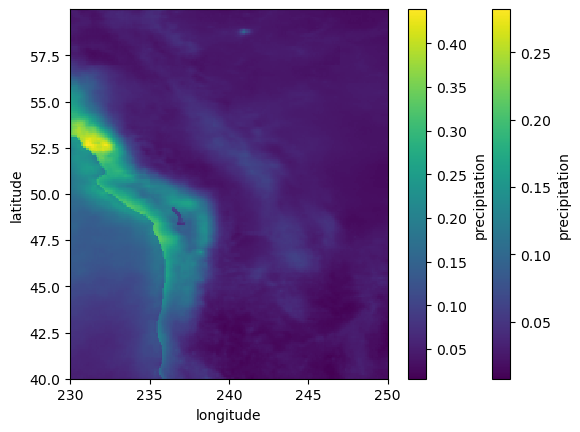

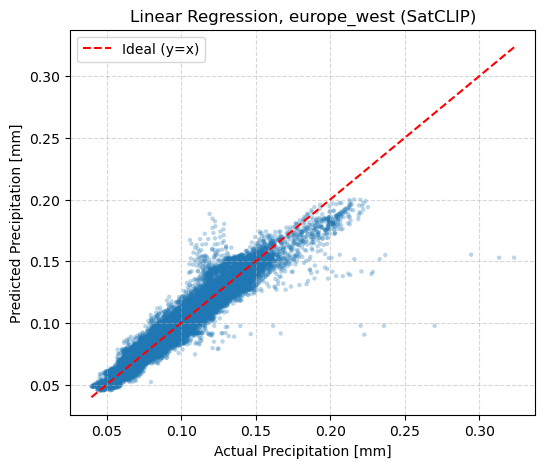

Evaluating on test region: blacksea
--- Linear Regression, blacksea (SatCLIP) ---
MSE: 0.047018873883746426
R2: -80.91786452229275
Deterministic CRPS (MAE): 0.1772
95th Percentile MAE: 0.4174
99th Percentile MAE: 0.4801



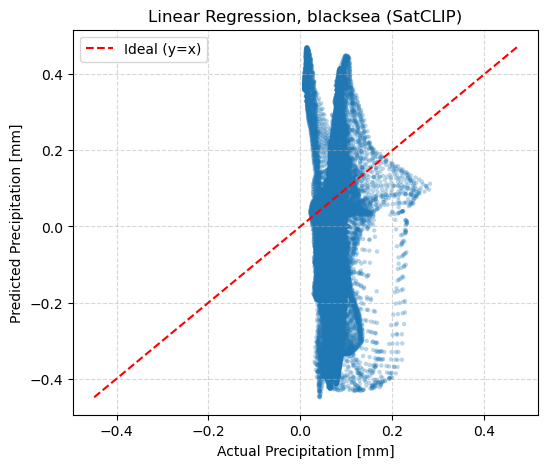

Evaluating on test region: northamerica-west
--- Linear Regression, northamerica-west (SatCLIP) ---
MSE: 0.049109891109303236
R2: -11.481675733615116
Deterministic CRPS (MAE): 0.1829
95th Percentile MAE: 0.4040
99th Percentile MAE: 0.4434



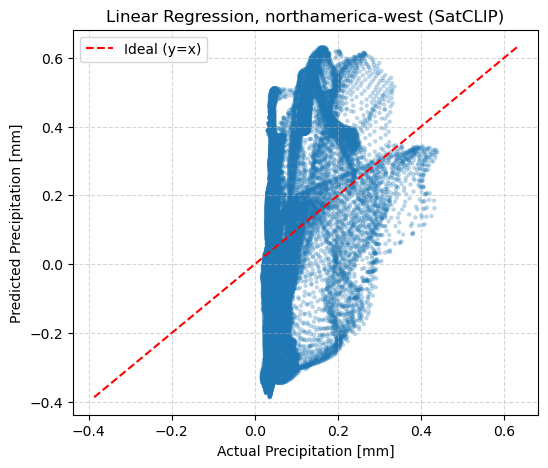

Evaluating on test region: west-africa
--- Linear Regression, west-africa (SatCLIP) ---
MSE: 0.07906533827940901
R2: -13.648046496737724
Deterministic CRPS (MAE): 0.2286
95th Percentile MAE: 0.5175
99th Percentile MAE: 0.6185



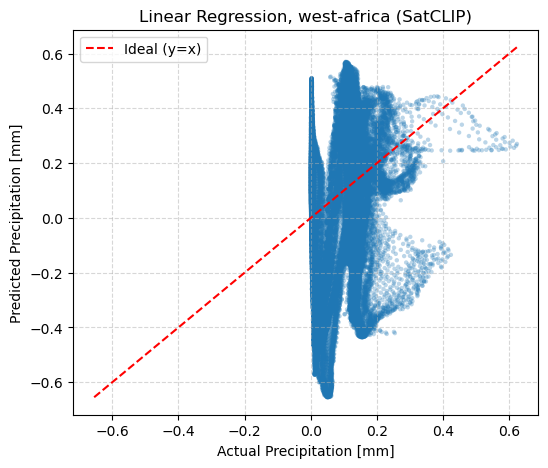

Evaluating on training data:
--- MLP, train region europe_west (SatCLIP) ---
MSE: 0.00020275980681946218
R2: 0.6701183475282793
Deterministic CRPS (MAE): 0.0111
95th Percentile MAE: 0.0281
99th Percentile MAE: 0.0373



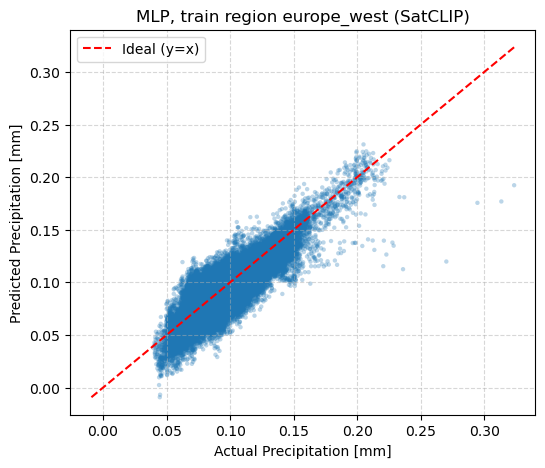

Evaluating on test region: blacksea
--- MLP, test region blacksea (SatCLIP) ---
MSE: 0.6166913655623653
R2: -1073.4204521169681
Deterministic CRPS (MAE): 0.6569
95th Percentile MAE: 1.4218
99th Percentile MAE: 1.7556



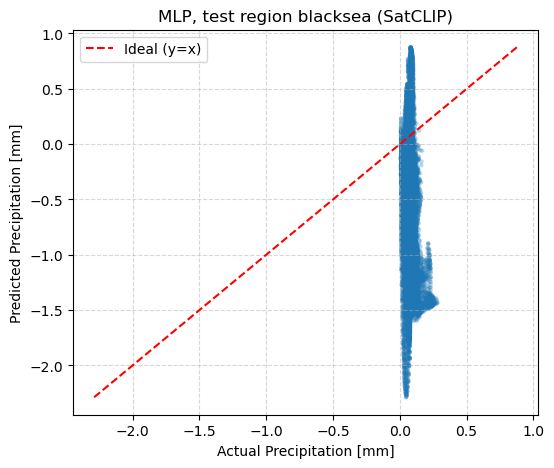

Evaluating on test region: northamerica-west
--- MLP, test region northamerica-west (SatCLIP) ---
MSE: 0.6173700618253566
R2: -155.90959082347163
Deterministic CRPS (MAE): 0.5587
95th Percentile MAE: 1.7763
99th Percentile MAE: 2.2896



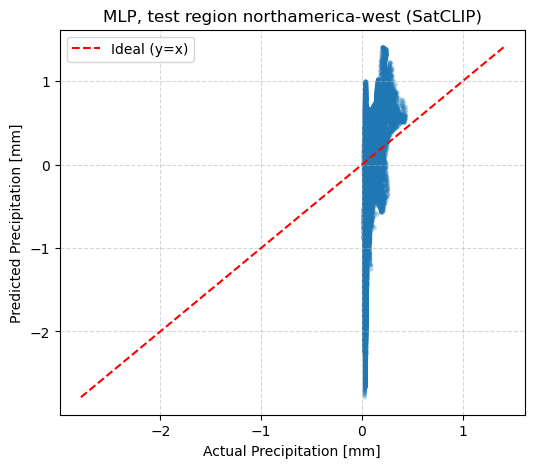

Evaluating on test region: west-africa
--- MLP, test region west-africa (SatCLIP) ---
MSE: 2.1565327027850545
R2: -398.5302112096025
Deterministic CRPS (MAE): 1.2522
95th Percentile MAE: 2.5655
99th Percentile MAE: 3.4860



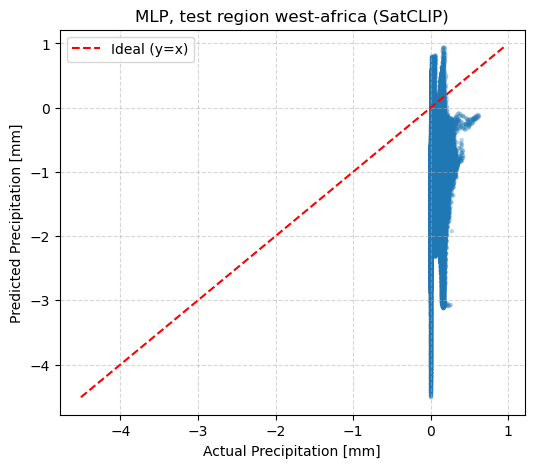

In [22]:
metrics = {}

X_train, y_train, X_test_by_region, y_test_by_region = get_splits_using_embedding(train_out_ds, test_out_ds_by_region, embedding="satclip")

metrics = eval_models(X_train, y_train, X_test_by_region, y_test_by_region, embedding="SatCLIP", metrics=metrics)

train region: europe_west


Train shapes: X=(40000, 20), y=(40000,)
Processing test region: blacksea
Train shapes: X=(40000, 20), y=(40000,)
Processing test region: northamerica-west
Train shapes: X=(40000, 20), y=(40000,)
Processing test region: west-africa
Train shapes: X=(40000, 20), y=(40000,)
Evaluating on training data:
--- Linear Regression, europe_west (Sinusoidal) ---
MSE: 0.00040420275763608515
R2: 0.34237921237945557
Deterministic CRPS (MAE): 0.0150
95th Percentile MAE: 0.0412
99th Percentile MAE: 0.0614



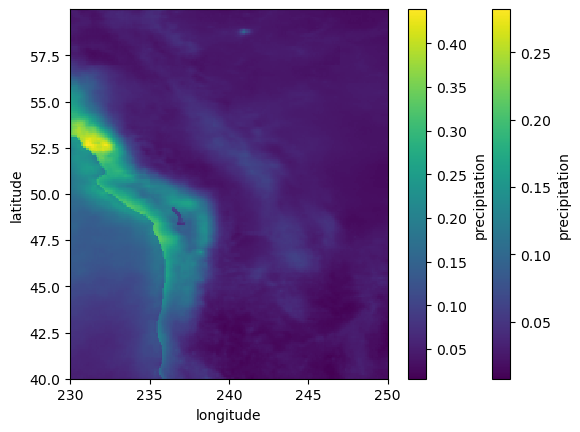

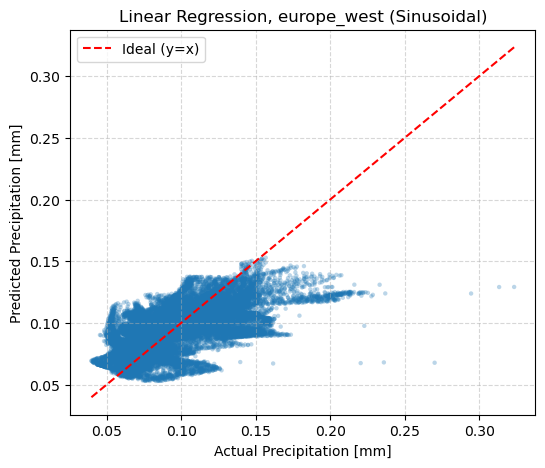

Evaluating on test region: blacksea
--- Linear Regression, blacksea (Sinusoidal) ---
MSE: 0.05222107470035553
R2: -89.98130798339844
Deterministic CRPS (MAE): 0.2147
95th Percentile MAE: 0.3202
99th Percentile MAE: 0.3307



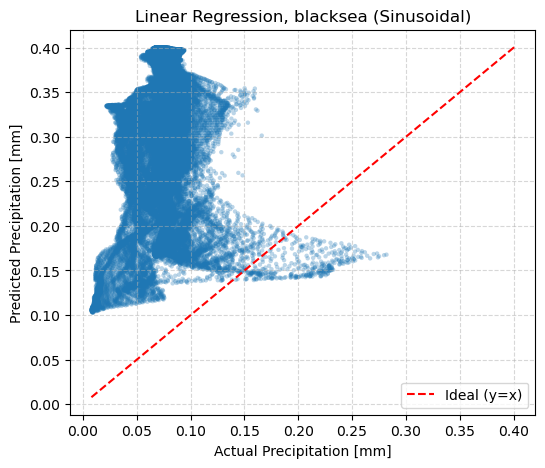

Evaluating on test region: northamerica-west
--- Linear Regression, northamerica-west (Sinusoidal) ---
MSE: 0.03922296315431595
R2: -8.968832015991211
Deterministic CRPS (MAE): 0.1743
95th Percentile MAE: 0.3474
99th Percentile MAE: 0.3711



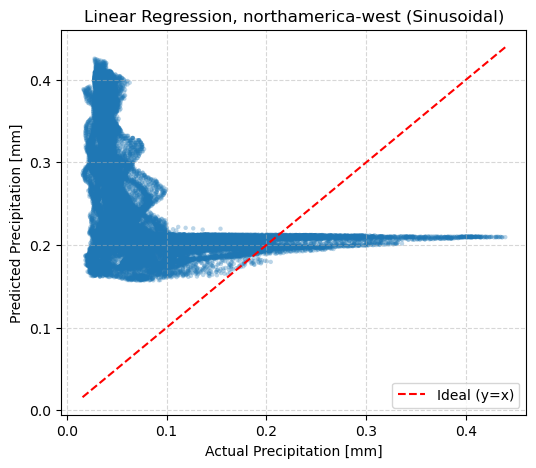

Evaluating on test region: west-africa
--- Linear Regression, west-africa (Sinusoidal) ---
MSE: 0.008895130828022957
R2: -0.6479573249816895
Deterministic CRPS (MAE): 0.0764
95th Percentile MAE: 0.1962
99th Percentile MAE: 0.2514



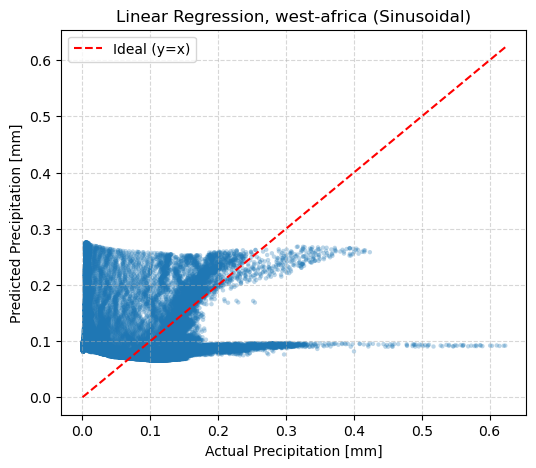

Evaluating on training data:
--- MLP, train region europe_west (Sinusoidal) ---
MSE: 4.9859365390148014e-05
R2: 0.9188809394836426
Deterministic CRPS (MAE): 0.0047
95th Percentile MAE: 0.0129
99th Percentile MAE: 0.0229



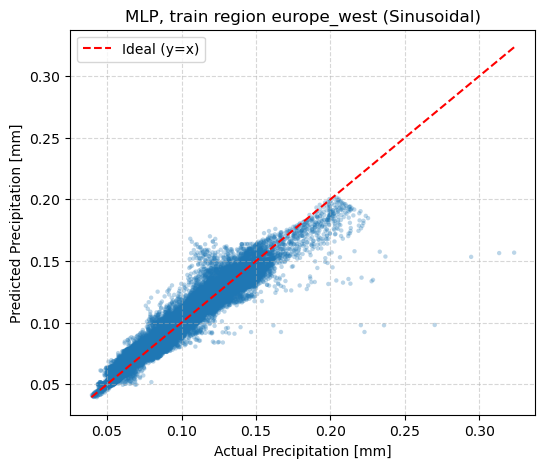

Evaluating on test region: blacksea
--- MLP, test region blacksea (Sinusoidal) ---
MSE: 0.009890603832900524
R2: -16.231740951538086
Deterministic CRPS (MAE): 0.0759
95th Percentile MAE: 0.2103
99th Percentile MAE: 0.2421



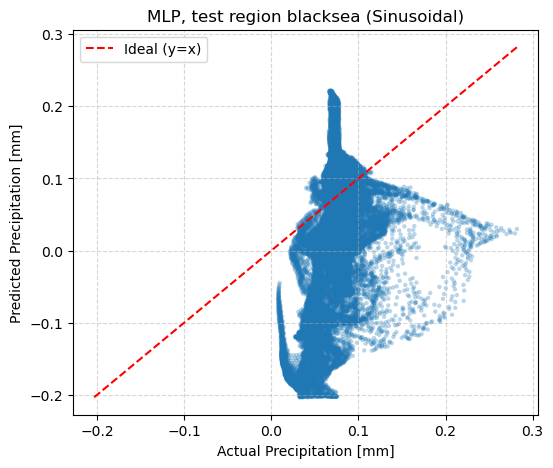

Evaluating on test region: northamerica-west
--- MLP, test region northamerica-west (Sinusoidal) ---
MSE: 0.014098440296947956
R2: -2.5832324028015137
Deterministic CRPS (MAE): 0.1010
95th Percentile MAE: 0.2143
99th Percentile MAE: 0.2598



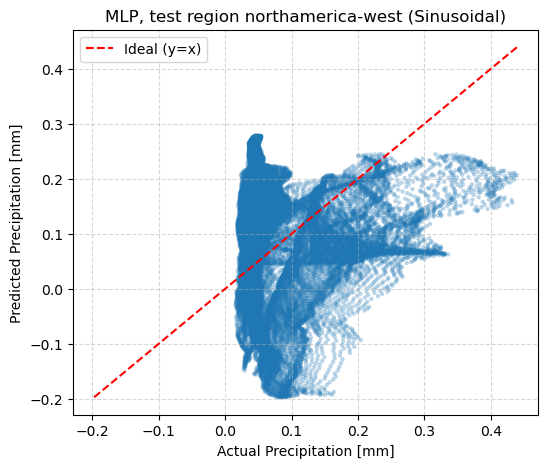

Evaluating on test region: west-africa
--- MLP, test region west-africa (Sinusoidal) ---
MSE: 0.06355904787778854
R2: -10.775274276733398
Deterministic CRPS (MAE): 0.1978
95th Percentile MAE: 0.4534
99th Percentile MAE: 0.5119



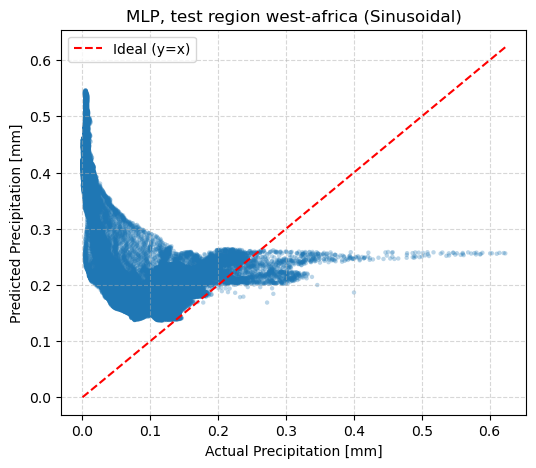

In [24]:
X_train, y_train, X_test_by_region, y_test_by_region = get_splits_using_embedding(train_out_ds, test_out_ds_by_region, embedding="sinusoidal")

metrics = eval_models(X_train, y_train, X_test_by_region, y_test_by_region, embedding="Sinusoidal", metrics=metrics)

train region: europe_west


Loading cached AlphaEarth embeddings...
Train shapes: X=(40000, 64), y=(40000,)
Processing test region: blacksea
Loading cached AlphaEarth embeddings...
Train shapes: X=(40000, 64), y=(40000,)
Processing test region: northamerica-west
Loading cached AlphaEarth embeddings...
Train shapes: X=(40000, 64), y=(40000,)
Processing test region: west-africa
Loading cached AlphaEarth embeddings...
Train shapes: X=(40000, 64), y=(40000,)
Evaluating on training data:
--- Linear Regression, europe_west (AlphaEarth) ---
MSE: 0.0002884918940253556
R2: 0.5306358337402344
Deterministic CRPS (MAE): 0.0128
95th Percentile MAE: 0.0343
99th Percentile MAE: 0.0492



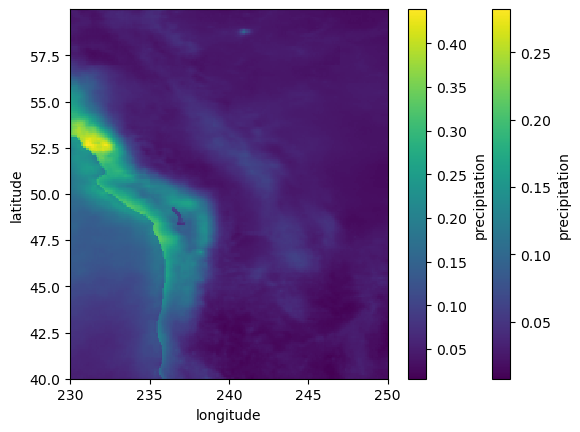

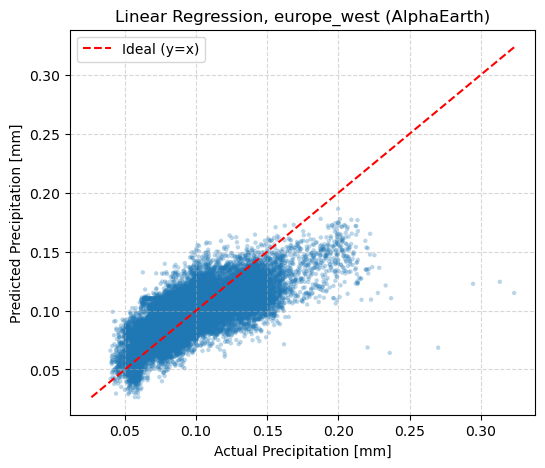

Evaluating on test region: blacksea
--- Linear Regression, blacksea (AlphaEarth) ---
MSE: 0.0007319992291741073
R2: -0.27531373500823975
Deterministic CRPS (MAE): 0.0215
95th Percentile MAE: 0.0502
99th Percentile MAE: 0.0755



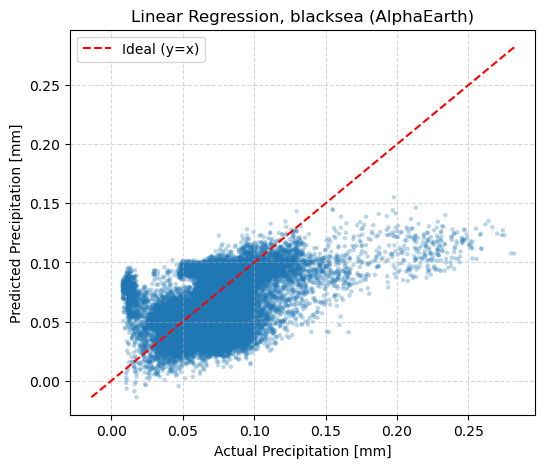

Evaluating on test region: northamerica-west
--- Linear Regression, northamerica-west (AlphaEarth) ---
MSE: 0.0016556924674659967
R2: 0.5791923999786377
Deterministic CRPS (MAE): 0.0280
95th Percentile MAE: 0.0824
99th Percentile MAE: 0.1505



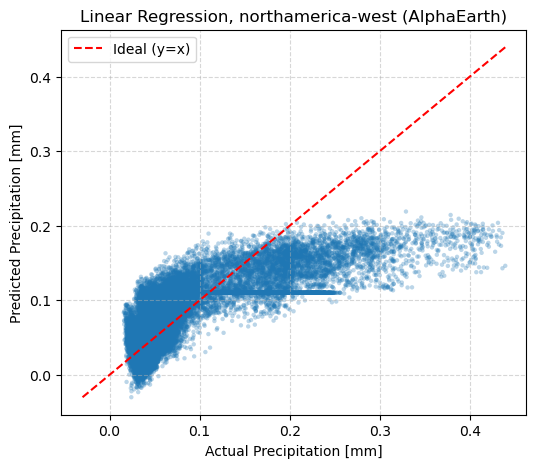

Evaluating on test region: west-africa
--- Linear Regression, west-africa (AlphaEarth) ---
MSE: 0.00946098379790783
R2: -0.752790093421936
Deterministic CRPS (MAE): 0.0803
95th Percentile MAE: 0.1730
99th Percentile MAE: 0.2147



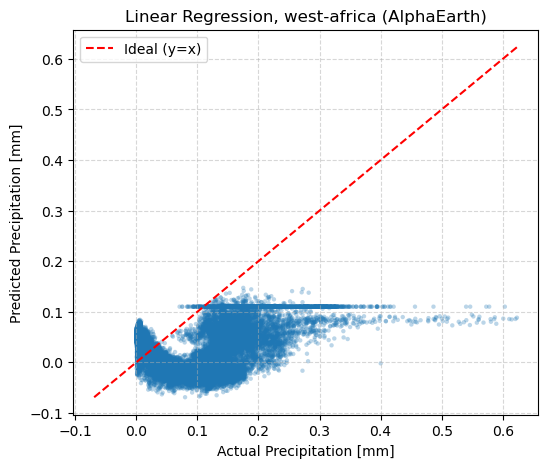

Evaluating on training data:
--- MLP, train region europe_west (AlphaEarth) ---
MSE: 0.00020246297935955226
R2: 0.6706012487411499
Deterministic CRPS (MAE): 0.0106
95th Percentile MAE: 0.0296
99th Percentile MAE: 0.0419



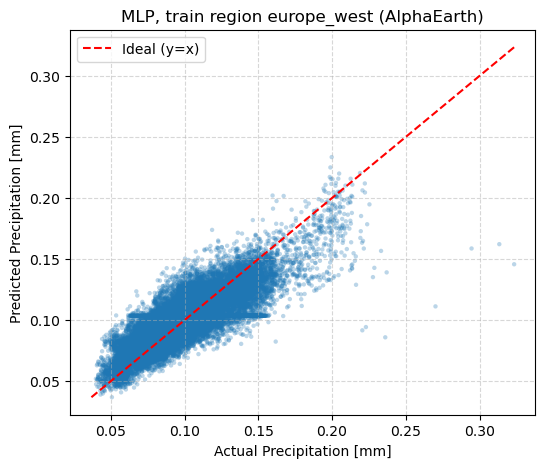

Evaluating on test region: blacksea
--- MLP, test region blacksea (AlphaEarth) ---
MSE: 0.00046697931247763336
R2: 0.18641293048858643
Deterministic CRPS (MAE): 0.0163
95th Percentile MAE: 0.0401
99th Percentile MAE: 0.0662



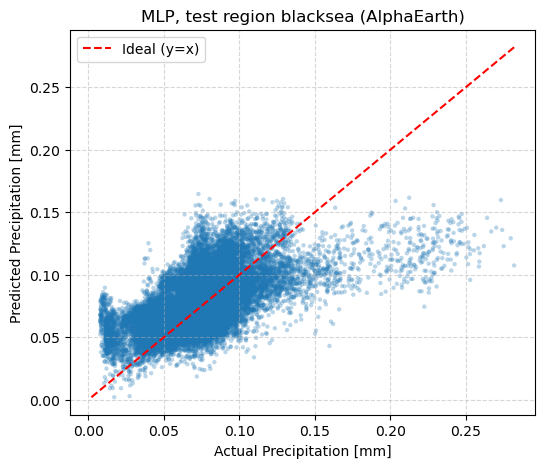

Evaluating on test region: northamerica-west
--- MLP, test region northamerica-west (AlphaEarth) ---
MSE: 0.0014928719028830528
R2: 0.6205745935440063
Deterministic CRPS (MAE): 0.0283
95th Percentile MAE: 0.0753
99th Percentile MAE: 0.1342



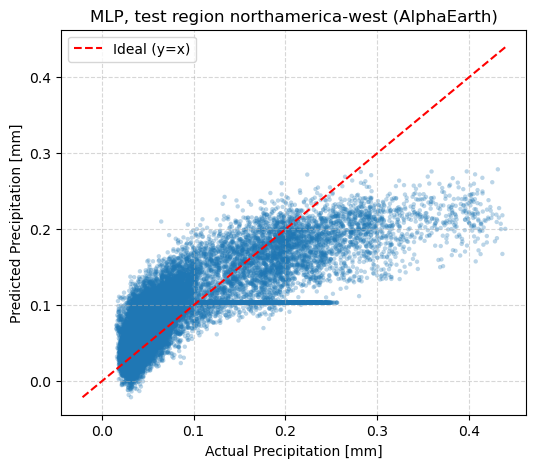

Evaluating on test region: west-africa
--- MLP, test region west-africa (AlphaEarth) ---
MSE: 0.005506005138158798
R2: -0.020070552825927734
Deterministic CRPS (MAE): 0.0605
95th Percentile MAE: 0.1308
99th Percentile MAE: 0.2019



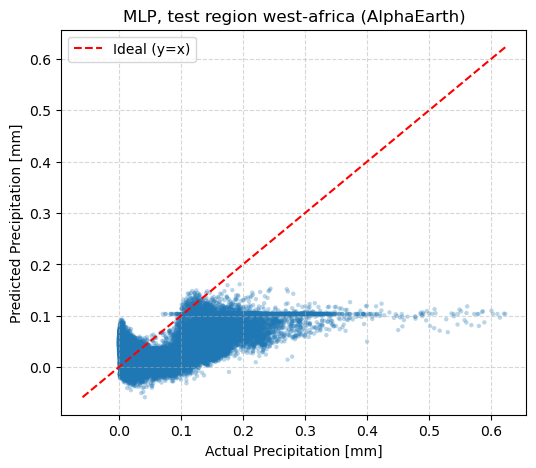

In [25]:
X_train, y_train, X_test_by_region, y_test_by_region = get_splits_using_embedding(train_out_ds, test_out_ds_by_region, embedding="alphaearth")

metrics = eval_models(X_train, y_train, X_test_by_region, y_test_by_region, embedding="AlphaEarth", metrics=metrics)

# TODO: mask ocean points in training and eval? build mask and pass it into something

In [33]:
import pandas as pd

metrics_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['MSE', 'R2', 'MAE', 'MAE_95', 'MAE_99'])
metrics_df.to_csv("embedding_transfer_metrics.csv")
metrics_df

,MSE,R2,MAE,MAE_95,MAE_99
SatCLIP_LR_europe_west,0.000046,0.925707,0.004402,0.012483,0.021717
SatCLIP_LR_blacksea,0.047019,-80.917865,0.177223,0.417382,0.480139
SatCLIP_LR_northamerica-west,0.049110,-11.481676,0.182908,0.403962,0.443388
SatCLIP_LR_west-africa,0.079065,-13.648046,0.228617,0.517454,0.618535
SatCLIP_MLP_europe_west,0.000203,0.670118,0.011141,0.028066,0.037320
SatCLIP_MLP_blacksea,0.616691,-1073.420452,0.656879,1.421803,1.755594
SatCLIP_MLP_northamerica-west,0.617370,-155.909591,0.558666,1.776300,2.289626
SatCLIP_MLP_west-africa,2.156533,-398.530211,1.252160,2.565540,3.485990
Sinusoidal_LR_europe_west,0.000404,0.342379,0.015047,0.041193,0.061450
Sinusoidal_LR_blacksea,0.052221,-89.981308,0.214685,0.320211,0.330677


In [35]:
lr_metrics = {k.replace("LR_", ""): v for k, v in metrics.items() if "LR" in k}
lr_metrics_df = pd.DataFrame.from_dict(lr_metrics, orient='index', columns=['MSE', 'R2', 'MAE', 'MAE_95', 'MAE_99'])
lr_metrics_df

,MSE,R2,MAE,MAE_95,MAE_99
SatCLIP_europe_west,0.000046,0.925707,0.004402,0.012483,0.021717
SatCLIP_blacksea,0.047019,-80.917865,0.177223,0.417382,0.480139
SatCLIP_northamerica-west,0.049110,-11.481676,0.182908,0.403962,0.443388
SatCLIP_west-africa,0.079065,-13.648046,0.228617,0.517454,0.618535
Sinusoidal_europe_west,0.000404,0.342379,0.015047,0.041193,0.061450
Sinusoidal_blacksea,0.052221,-89.981308,0.214685,0.320211,0.330677
Sinusoidal_northamerica-west,0.039223,-8.968832,0.174343,0.347426,0.371051
Sinusoidal_west-africa,0.008895,-0.647957,0.076360,0.196155,0.251368
AlphaEarth_europe_west,0.000288,0.530636,0.012845,0.034252,0.049223
AlphaEarth_blacksea,0.000732,-0.275314,0.021507,0.050152,0.075534


In [36]:
mlp_metrics = {k.replace("MLP_", ""): v for k, v in metrics.items() if "MLP" in k}
mlp_metrics_df = pd.DataFrame.from_dict(mlp_metrics, orient='index', columns=['MSE', 'R2', 'MAE', 'MAE_95', 'MAE_99'])
mlp_metrics_df 

,MSE,R2,MAE,MAE_95,MAE_99
SatCLIP_europe_west,0.000203,0.670118,0.011141,0.028066,0.037320
SatCLIP_blacksea,0.616691,-1073.420452,0.656879,1.421803,1.755594
SatCLIP_northamerica-west,0.617370,-155.909591,0.558666,1.776300,2.289626
SatCLIP_west-africa,2.156533,-398.530211,1.252160,2.565540,3.485990
Sinusoidal_europe_west,0.000050,0.918881,0.004676,0.012933,0.022901
Sinusoidal_blacksea,0.009891,-16.231741,0.075921,0.210334,0.242121
Sinusoidal_northamerica-west,0.014098,-2.583232,0.101025,0.214337,0.259832
Sinusoidal_west-africa,0.063559,-10.775274,0.197765,0.453414,0.511853
AlphaEarth_europe_west,0.000202,0.670601,0.010551,0.029551,0.041899
AlphaEarth_blacksea,0.000467,0.186413,0.016297,0.040114,0.066193


In [ ]:
X_train, y_train, X_test_by_region, y_test_by_region = get_splits_using_embedding(train_out_ds, test_out_ds_by_region, embedding="alphaearth")

alphaearth_metrics = eval_models(X_train, y_train, X_test_by_region, y_test_by_region, embedding="AlphaEarth")

# TODO: mask ocean points in training and eval? build mask and pass it into something

train region: europe_west
Train shapes: X=(40000, 64), y=(40000,)
Processing test region: blacksea
